# Módulo Visualização de Dados:

Leia o arquivo ecommerce_preparados.csv’ dentro de um dataframe  

Faça uma análise detalhada dos dados, descubra quais dados gostaria de destacar e crie os seguintes gráficos:


*   1 Gráfico de dispersão
*   1 Mapa de calor
*   1 Gráfico de barra
*   1 Gráfico de pizza
*   1 Gráfico de densidade

Adicione títulos nos gráficos e nos eixos para ficar claro os objetivos dos gráficos.

Fiquem a vontade para escolher a biblioteca que quiserem, não esqueçam de comentar os códigos.

Essa atividade é um pouco diferente, vocês terão que construir os códigos nesse arquivo e enviar ou o arquivo ou o link do github com o arquivo publicado para os tutores.

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configs

In [21]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Import Data

In [22]:
df = pd.read_csv('/app/data/ecommerce_preparados.csv')

# Initial Analyses

In [23]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           2199 non-null   int64  
 1   Título               2199 non-null   str    
 2   Nota                 1559 non-null   float64
 3   N_Avaliações         1559 non-null   float64
 4   Desconto             874 non-null    float64
 5   Marca                2199 non-null   str    
 6   Material             1332 non-null   str    
 7   Gênero               2120 non-null   str    
 8   Temporada            2199 non-null   str    
 9   Review1              1515 non-null   str    
 10  Review2              1354 non-null   str    
 11  Review3              1233 non-null   str    
 12  Qtd_Vendidos         2199 non-null   str    
 13  Preço                1964 non-null   float64
 14  Nota_MinMax          1559 non-null   float64
 15  N_Avaliações_MinMax  1559 non-null   float64
 16 

,Unnamed: 0,Nota,N_Avaliações,Desconto,Preço,Nota_MinMax,N_Avaliações_MinMax,Desconto_MinMax,Preço_MinMax,Marca_Cod,Material_Cod,Temporada_Cod,Qtd_Vendidos_Cod,Marca_Freq,Material_Freq
count,2199.000000,1559.000000,1559.000000,874.000000,1964.000000,1559.000000,1559.000000,874.000000,1964.000000,2199.000000,2199.000000,2199.000000,1973.000000,2199.000000,1332.000000
mean,1102.356526,4.560936,204.062219,15.457666,102.705713,0.837384,0.022374,0.171437,0.156587,440.440655,118.055935,3.418372,728.044602,0.006109,0.080198
std,637.791961,0.362854,578.455265,10.929166,69.976425,0.134390,0.063735,0.179167,0.119328,237.064233,60.987133,2.714090,3621.819900,0.009910,0.073812
min,0.000000,2.300000,1.000000,5.000000,10.880000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000455,0.000455
25%,549.500000,4.400000,8.000000,8.000000,50.192500,0.777778,0.000771,0.049180,0.067038,239.500000,62.500000,1.000000,5.000000,0.000910,0.005457
50%,1103.000000,4.600000,27.000000,11.000000,78.970000,0.851852,0.002865,0.098361,0.116111,463.000000,122.000000,3.000000,50.000000,0.001819,0.030014
75%,1654.500000,4.800000,119.500000,20.000000,139.152500,0.925926,0.013056,0.245902,0.218738,642.500000,178.000000,7.000000,100.000000,0.007731,0.176444
max,2206.000000,5.000000,9077.000000,66.000000,597.300000,1.000000,1.000000,1.000000,1.000000,841.000000,178.000000,9.000000,50000.000000,0.042292,0.176444


In [24]:
df['Qtd_Vendidos'] = pd.to_numeric(df['Qtd_Vendidos'], errors='coerce')

# Histogram

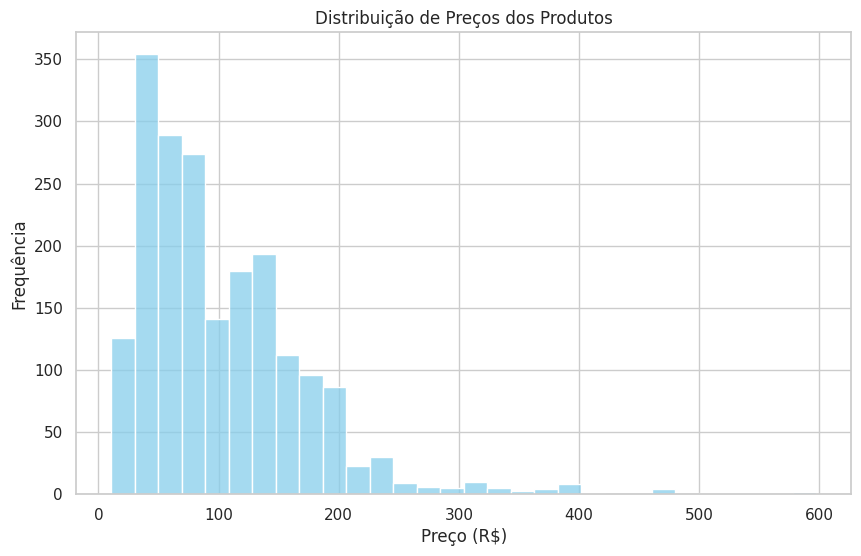

In [25]:
plt.figure()
sns.histplot(df['Preço'], bins=30, kde=False, color='skyblue')
plt.title('Distribuição de Preços dos Produtos')
plt.xlabel('Preço (R$)')
plt.ylabel('Frequência')
plt.show()

# Scatter Plot

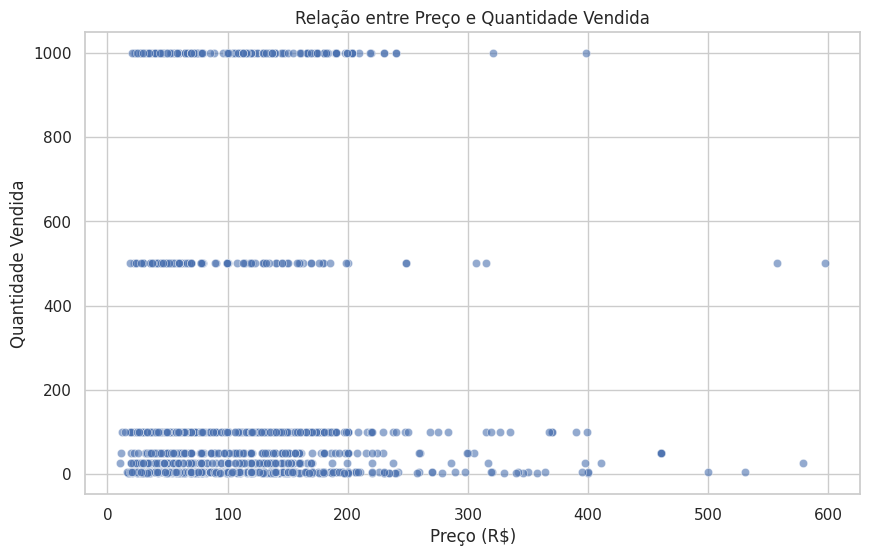

In [26]:
plt.figure()
sns.scatterplot(data=df, x='Preço', y='Qtd_Vendidos', alpha=0.6)
plt.title('Relação entre Preço e Quantidade Vendida')
plt.xlabel('Preço (R$)')
plt.ylabel('Quantidade Vendida')
plt.show()

# Heatmap

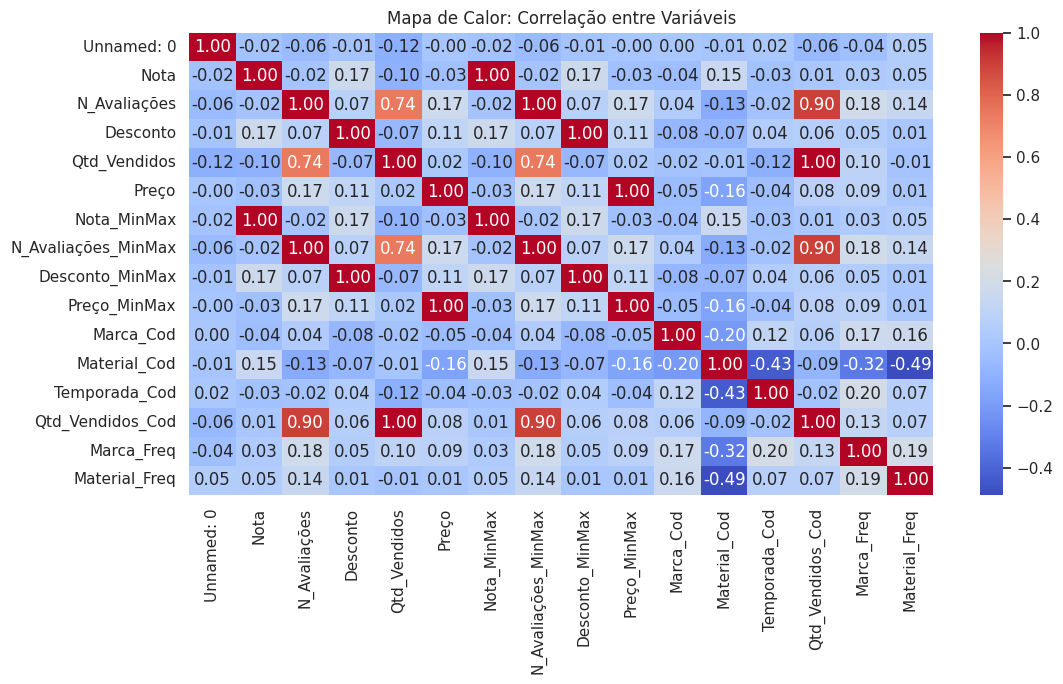

In [27]:
plt.figure(figsize=(12, 6))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor: Correlação entre Variáveis')
plt.show()

# Bar Chart

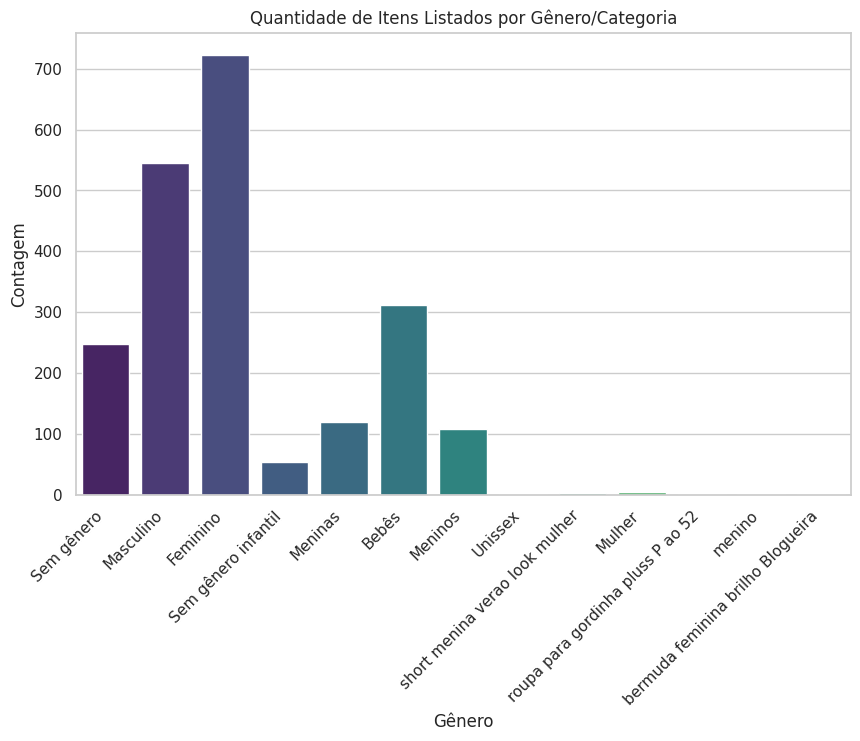

In [ ]:
plt.figure()
sns.countplot(data=df, x='Gênero', hue='Gênero', palette='viridis', legend=False)
plt.title('Quantidade de Itens Listados por Gênero/Categoria')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels by 45 degrees and align them to the right to prevent overlapping
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show()

# Pie Chart

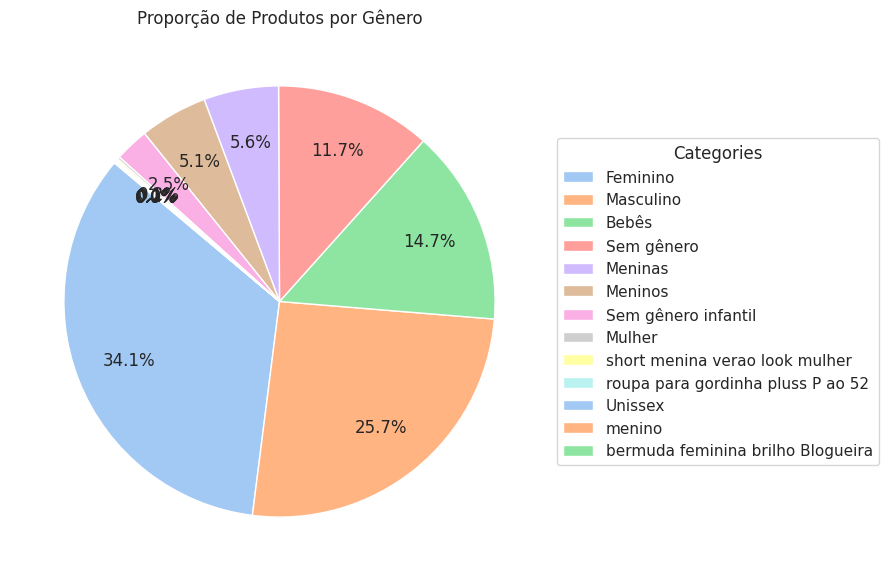

In [41]:
plt.figure(figsize=(10, 7))
contagem_genero = df['Gênero'].value_counts()

# Create the pie chart without direct labels to avoid text overlapping
# pctdistance=0.75 positions the percentages inside the slices clearly
patches, texts, autotexts = plt.pie(contagem_genero, 
                                    autopct='%1.1f%%', 
                                    startangle=140, 
                                    colors=sns.color_palette('pastel'),
                                    pctdistance=0.75)

# Add a side legend to identify categories without cluttering the chart
# bbox_to_anchor moves the legend outside the plot area to the right
plt.legend(patches, contagem_genero.index, 
           title="Categories", 
           loc="center left", 
           bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Proporção de Produtos por Gênero')
plt.show()

# Density Chart

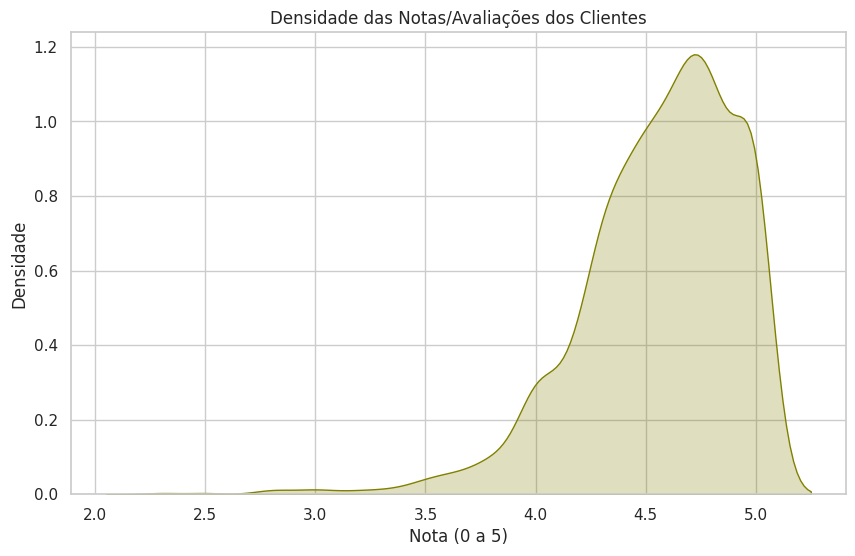

In [30]:
plt.figure()
sns.kdeplot(df['Nota'], fill=True, color="olive")
plt.title('Densidade das Notas/Avaliações dos Clientes')
plt.xlabel('Nota (0 a 5)')
plt.ylabel('Densidade')
plt.show()

In [31]:
# Regression Chart

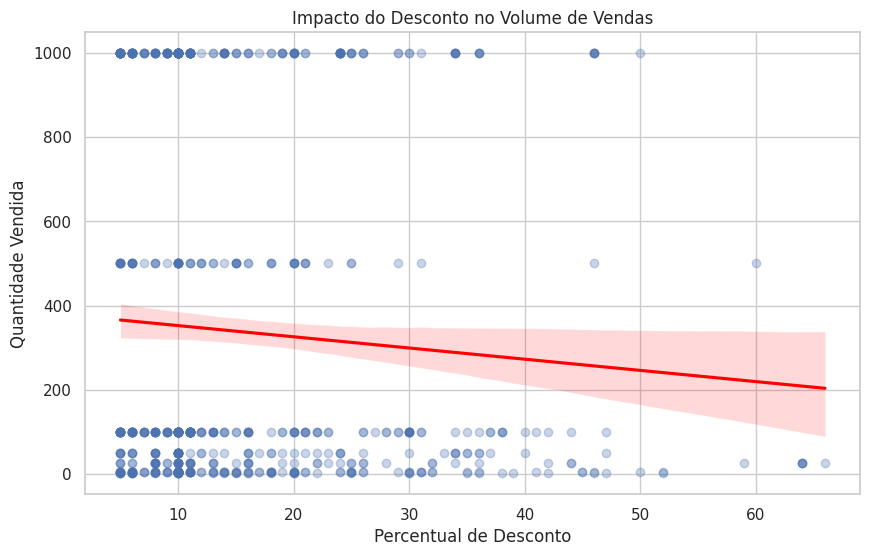

In [32]:
plt.figure()
sns.regplot(data=df, x='Desconto', y='Qtd_Vendidos', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Impacto do Desconto no Volume de Vendas')
plt.xlabel('Percentual de Desconto')
plt.ylabel('Quantidade Vendida')
plt.show()